In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import kagglehub
import os
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("japkeeratsingh/youtube-videos-and-the-comments")
file_path = os.path.join(path, "YT_Videos_Comments.csv")

df = pd.read_csv(file_path)


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.42MB/s]

Extracting files...



C:\Users\Mahmoud Ibrahim\AppData\Local\Temp\ipykernel_20448\2464861798.py:4: DtypeWarning: Columns (2,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.head()

,User,Video Title,Video Description,Video ID,Comment (Displayed),Comment (Actual),Comment Author,Comment Author Channel ID,Comment Time
0,Cleo Abram,"Robots made of spiders (yes, really)",I'M SORRY OK. But this is fascinating. \n\nSci...,YXd4z3gWyVE,zombie spider!! bomb the damn lab before it&#3...,zombie spider!! bomb the damn lab before it's ...,Bagus Hutomo,UC-F6GFyxAqGhN3_MEJLksxg,2023-03-11T07:39:33Z
1,Cleo Abram,"Robots made of spiders (yes, really)",I'M SORRY OK. But this is fascinating. \n\nSci...,YXd4z3gWyVE,"This is way less cool than it seems, spiders a...","This is way less cool than it seems, spiders a...",CMZ neu,UCZKnVEtNze-fFxCvsRnaIuA,2023-03-11T05:26:10Z
2,Cleo Abram,"Robots made of spiders (yes, really)",I'M SORRY OK. But this is fascinating. \n\nSci...,YXd4z3gWyVE,Spiders see this and this is why they made the...,Spiders see this and this is why they made the...,Kiana Marrie,UCutp6oeKAxsO6fXp1vyzvIQ,2023-03-11T04:02:27Z
3,Cleo Abram,"Robots made of spiders (yes, really)",I'M SORRY OK. But this is fascinating. \n\nSci...,YXd4z3gWyVE,you looks pretty 😍,you looks pretty 😍,Noob,UC9J99riIPd6ja-XDFSwrY-Q,2023-03-11T02:50:50Z
4,Cleo Abram,"Robots made of spiders (yes, really)",I'M SORRY OK. But this is fascinating. \n\nSci...,YXd4z3gWyVE,I can hear the hairs standing up on my wife’s ...,I can hear the hairs standing up on my wife’s ...,chancellor9000,UC8WEPXkCSh87h6kBcFT-o1g,2023-03-11T02:46:02Z


In [4]:
df['Video Description'].value_counts()

Video Description
Physics Girl                                                                                                                                                                                     56987
Is                                                                                                                                                                                               55275
It&#39;s a primitive clash                                                                                                                                                                       52316
So let me get this straight... You are looking into a  theoretical particle that is created by a theoretical force?<br>Why are you pretending The electric universe theory / Plasma cosmology    44223
<a href="https://www.youtube.com/watch?v=yFRPhi0jhGc&amp;t=6m26s">6:26</a> Kickflips had been done.\r Shove-its had been done. But impossible had not been done.                          

In [5]:
df.isnull().sum()

User                              0
Video Title                     149
Video Description            196767
Video ID                     429330
Comment (Displayed)          467375
Comment (Actual)             482881
Comment Author               482968
Comment Author Channel ID    482868
Comment Time                 482862
dtype: int64

In [6]:
df.shape

(861962, 9)

In [7]:
df.drop(['Video ID', 'Comment Author Channel ID', 'Video Description', 'Comment Time','Video Title', 'Comment (Displayed)', 'Comment Author'], axis=1, inplace=True)

In [8]:
df.head()

,User,Comment (Actual)
0,Cleo Abram,zombie spider!! bomb the damn lab before it's ...
1,Cleo Abram,"This is way less cool than it seems, spiders a..."
2,Cleo Abram,Spiders see this and this is why they made the...
3,Cleo Abram,you looks pretty 😍
4,Cleo Abram,I can hear the hairs standing up on my wife’s ...


In [9]:
df['User'].isnull().sum()

0

In [10]:
mode_value = df['Comment (Actual)'].mode()[0]
df['Comment (Actual)'] = df['Comment (Actual)'].fillna(mode_value)

In [11]:
df.shape

(861962, 2)

In [12]:
from nltk.corpus import stopwords
import re
from nltk.stem import PorterStemmer

In [13]:
df.reset_index(inplace=True)

In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Mahmoud
[nltk_data]     Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
corpus= []
for i in range(0, len(df)):
    review = re.sub(r"http\S+|www\S+", "", df['Comment (Actual)'][i])
    review = re.sub(r"[^a-zA-Z]", " ", df['Comment (Actual)'][i])
    review = re.sub('[^a-zA-Z]', ' ', df['Comment (Actual)'][i])
    review = review.lower()
    review = review.split()

    all_stopwords = stopwords.words('english')
    all_stopwords.remove('not')

    ps= PorterStemmer()

    review = [ps.stem(word) for word in review if not word in set(all_stopwords)]

    review = ' '.join(review)
    corpus.append(review)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(max_features = 1000)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:,-1].values

In [18]:
from sklearn.preprocessing import StandardScaler
X= X.astype('float16')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

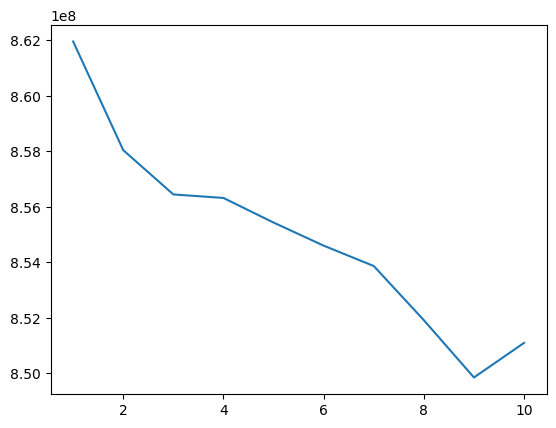

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
cs = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init= 'k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)

plt.plot(range(1,11), cs)

In [24]:
best_kmean = KMeans(n_clusters=3, init= 'k-means++', max_iter= 300, n_init= 10, random_state=0)
best_kmean.fit(X_scaled)
cluster_labels = best_kmean.predict(X_scaled)

In [23]:
df['Cluster'] = cluster_labels
df.head()

,index,User,Comment (Actual),Cluster
0,0,Cleo Abram,zombie spider!! bomb the damn lab before it's ...,1
1,1,Cleo Abram,"This is way less cool than it seems, spiders a...",2
2,2,Cleo Abram,Spiders see this and this is why they made the...,2
3,3,Cleo Abram,you looks pretty 😍,2
4,4,Cleo Abram,I can hear the hairs standing up on my wife’s ...,2


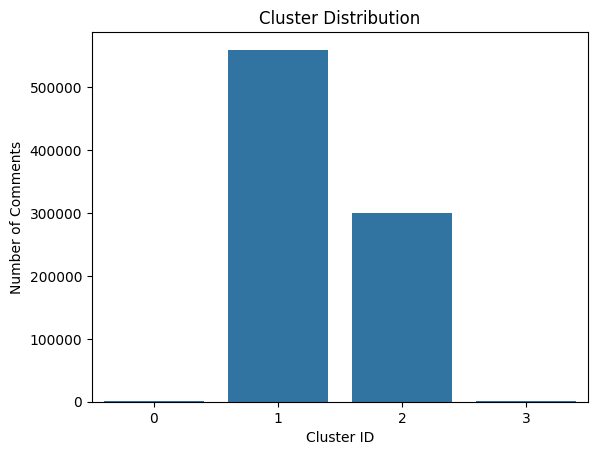

In [27]:
sns.countplot(x='Cluster', data=df)
plt.title('Cluster Distribution')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Comments')
plt.show()
